# Ensemble Modeling Notebook (Post-Improved Preprocessing)

This notebook continues from the improved workflow and builds a separate ensemble-focused pipeline.

We use ensemble techniques because individual models have complementary strengths - tree-based models capture non-linear interactions well, while linear/SVM models excel on the high-dimensional sensor features.

## Objectives
- Reproduce the improved preprocessing pipeline.
- Systematically rank individual candidate models.
- Build voting and stacking ensembles from the strongest models.
- Compare results against the classical baseline benchmark.

In [8]:
!pip install matplotlib seaborn

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:-

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)

# Optional XGBoost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

# Load prepared dataset files from baseline/improved workflow
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Ensure label indexing is compatible with all models (especially XGBoost)
if np.min(y_train) == 1 and np.max(y_train) == 6:
    y_train = y_train - 1
    y_test = y_test - 1

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", np.unique(y_train))

Train shape: (7352, 562)
Test shape: (2947, 562)
Classes: [0 1 2 3 4 5]


## Step 1 - Reuse Improved Preprocessing

We keep the same improved preprocessing strategy to remain comparable with your previous notebook:
1. Remove near-zero variance features.
2. Use ANOVA SelectKBest to preserve strongly discriminative features.
3. Remove highly correlated features to reduce redundancy.

After variance filter: 525 features kept
Best k from sweep: 525
After SelectKBest: 525 features
After correlation pruning: 257 features
Final train/test shapes: (7352, 257) (2947, 257)


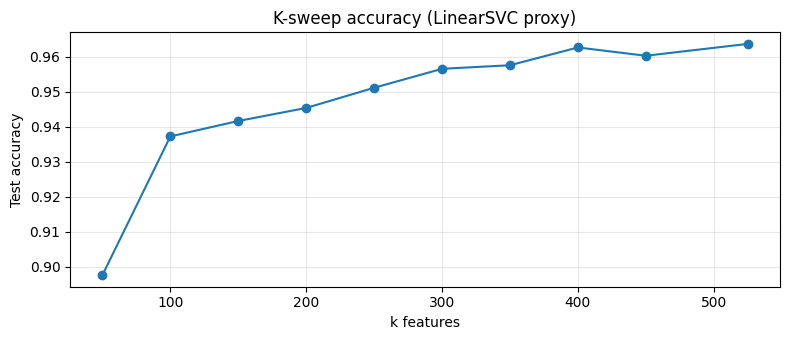

In [10]:
# 1) Near-zero variance filtering
VARIANCE_THRESHOLD = 0.01
var_selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X_train_clean = var_selector.fit_transform(X_train)
X_test_clean = var_selector.transform(X_test)

kept_cols = X_train.columns[var_selector.get_support()].tolist()
print(f"After variance filter: {X_train_clean.shape[1]} features kept")

# 2) K sweep using a strong linear proxy (LinearSVC)
k_values = [50, 100, 150, 200, 250, 300, 350, 400, 450, X_train_clean.shape[1]]
k_values = sorted(set([k for k in k_values if k <= X_train_clean.shape[1]]))

k_scores = []
for k in k_values:
    sel_tmp = SelectKBest(score_func=f_classif, k=k)
    Xtr_tmp = sel_tmp.fit_transform(X_train_clean, y_train)
    Xte_tmp = sel_tmp.transform(X_test_clean)

    proxy = LinearSVC(random_state=42, max_iter=5000)
    proxy.fit(Xtr_tmp, y_train)
    pred_tmp = proxy.predict(Xte_tmp)
    k_scores.append(accuracy_score(y_test, pred_tmp))

best_k = k_values[int(np.argmax(k_scores))]
print("Best k from sweep:", best_k)

# 3) Apply SelectKBest with best k
kb_selector = SelectKBest(score_func=f_classif, k=best_k)
X_train_kb = kb_selector.fit_transform(X_train_clean, y_train)
X_test_kb = kb_selector.transform(X_test_clean)

# 4) Correlation pruning (|r| > 0.95)
corr_matrix = np.corrcoef(X_train_kb, rowvar=False)
cols_to_drop = set()
for i in range(corr_matrix.shape[0]):
    if i in cols_to_drop:
        continue
    for j in range(i + 1, corr_matrix.shape[1]):
        if abs(corr_matrix[i, j]) > 0.95:
            cols_to_drop.add(j)

keep_mask = np.array([idx not in cols_to_drop for idx in range(X_train_kb.shape[1])])
X_train_sel = X_train_kb[:, keep_mask]
X_test_sel = X_test_kb[:, keep_mask]

print(f"After SelectKBest: {X_train_kb.shape[1]} features")
print(f"After correlation pruning: {X_train_sel.shape[1]} features")
print("Final train/test shapes:", X_train_sel.shape, X_test_sel.shape)

plt.figure(figsize=(8, 3.5))
plt.plot(k_values, k_scores, marker="o")
plt.title("K-sweep accuracy (LinearSVC proxy)")
plt.xlabel("k features")
plt.ylabel("Test accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2 - Systematic Individual Model Selection

To avoid arbitrary model picking, we rank candidate models with stratified cross-validation on the preprocessed training set, then retain the top performers for ensemble construction.

In [22]:
from models import get_models , get_improved_models

candidate_models = get_models()
candidate_models.update(get_improved_models())
candidate_models

{'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Linear SVC': LinearSVC(),
 'RBF SVM': SVC(C=10, random_state=42),
 'K-Nearest Neighbor': KNeighborsClassifier(),
 'Extra Trees': ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=42),
 'Hist Gradient Boosting': HistGradientBoostingClassifier(max_iter=300, random_state=42),
 'Tuned Random Forest': RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42),
 'Tuned Logistic Regression': LogisticRegression(C=10, max_iter=2000, n_jobs=-1, random_state=42,
                    solver='saga'),
 'Tuned RBF SVM': SVC(C=100, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9, device=None, early_stopping_rounds=None,
               ena

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, model in candidate_models.items():
    scores = cross_validate(
        model,
        X_train_sel,
        y_train,
        cv=cv,
        scoring={"acc": "accuracy", "f1w": "f1_weighted"},
        n_jobs=-1,
    )
    rows.append(
        {
            "Model": name,
            "CV Accuracy Mean": np.mean(scores["test_acc"]),
            "CV Accuracy Std": np.std(scores["test_acc"]),
            "CV F1-Weighted Mean": np.mean(scores["test_f1w"]),
        }
    )

cv_df = pd.DataFrame(rows).sort_values("CV Accuracy Mean", ascending=False).reset_index(drop=True)
cv_df.round(4)

,Model,CV Accuracy Mean,CV Accuracy Std,CV F1-Weighted Mean
0,Hist Gradient Boosting,0.9944,0.0014,0.9944
1,XGBoost,0.9924,0.0016,0.9924
2,Tuned RBF SVM,0.9882,0.0021,0.9882
3,Extra Trees,0.9844,0.0031,0.9843
4,Tuned Random Forest,0.9825,0.0024,0.9824
5,Random Forest,0.9808,0.0031,0.9808
6,Tuned Logistic Regression,0.9789,0.0041,0.9789
7,Linear SVC,0.9784,0.0039,0.9784
8,Logistic Regression,0.9771,0.0041,0.9771
9,RBF SVM,0.9752,0.0046,0.9752


In [25]:
scores

{'fit_time': array([49.90270758, 48.95648789, 48.48191023, 49.7439177 , 48.61747289]),
 'score_time': array([0.09984303, 0.09958482, 0.10797763, 0.07993579, 0.10300398]),
 'test_acc': array([0.99388171, 0.99388171, 0.99115646, 0.98979592, 0.99319728]),
 'test_f1w': array([0.99387914, 0.99388175, 0.99116713, 0.98979206, 0.9931936 ])}

In [26]:
top_n = 4
selected_names = cv_df.head(top_n)["Model"].tolist()
selected_names

['Hist Gradient Boosting', 'XGBoost', 'Tuned RBF SVM', 'Extra Trees']

## Step 3 - Build Ensembles from the Best Models

Ensemble design:
- **Hard Voting**: majority label voting across top-ranked diverse models.
- **Soft Voting**: probability averaging across probabilistic models (when available).
- **Stacking**: meta-learner combines base-model outputs to exploit complementary decision boundaries.

This directly operationalizes the rationale that model families capture different structure in HAR sensor features.

In [27]:
# Fit and evaluate selected individual models on held-out test set
summary_rows = []
fitted_models = {}

for name in selected_names:
    model = clone(candidate_models[name])
    model.fit(X_train_sel, y_train)
    pred = model.predict(X_test_sel)
    fitted_models[name] = model

    summary_rows.append(
        {
            "Model": name,
            "Type": "Individual",
            "Accuracy": accuracy_score(y_test, pred),
            "F1-Weighted": f1_score(y_test, pred, average="weighted"),
            "Precision-Weighted": precision_score(y_test, pred, average="weighted"),
            "Recall-Weighted": recall_score(y_test, pred, average="weighted"),
        }
    )

# Hard voting over all selected models
hard_estimators = [(name, clone(candidate_models[name])) for name in selected_names]
hard_vote = VotingClassifier(estimators=hard_estimators, voting="hard", n_jobs=-1)
hard_vote.fit(X_train_sel, y_train)
hard_pred = hard_vote.predict(X_test_sel)

summary_rows.append(
    {
        "Model": "Hard Voting (Top models)",
        "Type": "Ensemble",
        "Accuracy": accuracy_score(y_test, hard_pred),
        "F1-Weighted": f1_score(y_test, hard_pred, average="weighted"),
        "Precision-Weighted": precision_score(y_test, hard_pred, average="weighted"),
        "Recall-Weighted": recall_score(y_test, hard_pred, average="weighted"),
    }
)

# Soft voting only with models that support predict_proba
proba_names = [name for name in selected_names if hasattr(candidate_models[name], "predict_proba")]
if len(proba_names) >= 2:
    soft_estimators = [(name, clone(candidate_models[name])) for name in proba_names]
    soft_vote = VotingClassifier(estimators=soft_estimators, voting="soft", n_jobs=-1)
    soft_vote.fit(X_train_sel, y_train)
    soft_pred = soft_vote.predict(X_test_sel)

    summary_rows.append(
        {
            "Model": "Soft Voting (Proba models)",
            "Type": "Ensemble",
            "Accuracy": accuracy_score(y_test, soft_pred),
            "F1-Weighted": f1_score(y_test, soft_pred, average="weighted"),
            "Precision-Weighted": precision_score(y_test, soft_pred, average="weighted"),
            "Recall-Weighted": recall_score(y_test, soft_pred, average="weighted"),
        }
    )

# Stacking over selected models
stack_estimators = [(name, clone(candidate_models[name])) for name in selected_names]
stack_clf = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=3000, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False,
)
stack_clf.fit(X_train_sel, y_train)
stack_pred = stack_clf.predict(X_test_sel)

summary_rows.append(
    {
        "Model": "Stacking (Top models)",
        "Type": "Ensemble",
        "Accuracy": accuracy_score(y_test, stack_pred),
        "F1-Weighted": f1_score(y_test, stack_pred, average="weighted"),
        "Precision-Weighted": precision_score(y_test, stack_pred, average="weighted"),
        "Recall-Weighted": recall_score(y_test, stack_pred, average="weighted"),
    }
)

ensemble_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
ensemble_df.round(4)

,Model,Type,Accuracy,F1-Weighted,Precision-Weighted,Recall-Weighted
0,Stacking (Top models),Ensemble,0.9511,0.9510,0.9523,0.9511
1,Extra Trees,Individual,0.9505,0.9501,0.9521,0.9505
2,Hard Voting (Top models),Ensemble,0.9471,0.9469,0.9480,0.9471
3,Soft Voting (Proba models),Ensemble,0.9420,0.9418,0.9430,0.9420
4,XGBoost,Individual,0.9406,0.9404,0.9417,0.9406
5,Tuned RBF SVM,Individual,0.9393,0.9391,0.9405,0.9393
6,Hist Gradient Boosting,Individual,0.9382,0.9381,0.9391,0.9382


Best model/ensemble: Stacking (Top models)

Benchmark target range: 0.95 - 0.97
Achieved accuracy: 0.9511


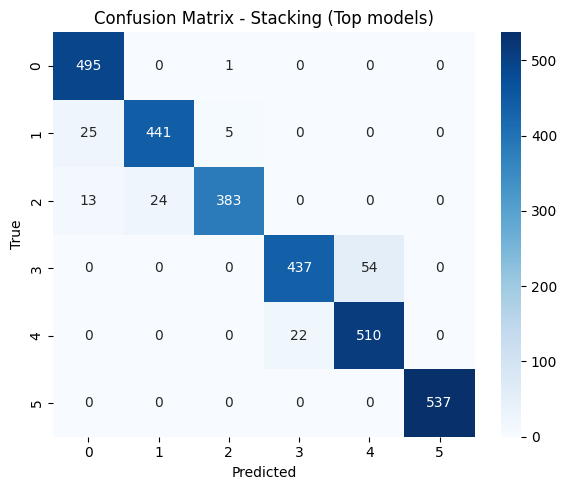

Saved: ensemble_results.csv


In [29]:
best_name = ensemble_df.iloc[0]["Model"]
print("Best model/ensemble:", best_name)
print("\nBenchmark target range: 0.95 - 0.97")
print("Achieved accuracy:", round(float(ensemble_df.iloc[0]["Accuracy"]), 4))

# Pick predictions from the best model for confusion matrix
if best_name == "Hard Voting (Top models)":
    best_pred = hard_pred
elif best_name == "Soft Voting (Proba models)" and "soft_pred" in globals():
    best_pred = soft_pred
elif best_name == "Stacking (Top models)":
    best_pred = stack_pred
else:
    best_model = fitted_models[best_name]
    best_pred = best_model.predict(X_test_sel)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

ensemble_df.to_csv("ensemble_results.csv", index=False)
print("Saved: ensemble_results.csv")